In [1]:
from dyn_model_class import ModelClass
from dyn_model_estim import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter

%reload_ext autoreload
%autoreload 2

In [2]:
### Load all data

# non-parents
df_pre_nonpar_u30 = pd.read_excel('Data/HR_pre_nonpar_u30.xlsx')
df_pre_nonpar_o30 = pd.read_excel('Data/HR_pre_nonpar_o30.xlsx')

df_pre_nonpar_u30_raw = pd.read_excel('Data/HR_pre_nonpar_u30_raw.xlsx')
df_pre_nonpar_o30_raw = pd.read_excel('Data/HR_pre_nonpar_o30_raw.xlsx')

df_pre_nonpar_o30_1 = pd.read_excel('Data/HR_pre_nonpar_o30_1.xlsx')
df_pre_nonpar_o30_2 = pd.read_excel('Data/HR_pre_nonpar_o30_2.xlsx')

df_post_nonpar_u30 = pd.read_excel('Data/HR_post_nonpar_u30.xlsx')
df_post_nonpar_o30 = pd.read_excel('Data/HR_post_nonpar_o30.xlsx')

df_post_nonpar_o30_raw = pd.read_excel('Data/HR_post_nonpar_o30_raw.xlsx')
df_post_nonpar_u30_raw = pd.read_excel('Data/HR_post_nonpar_u30_raw.xlsx')

df_post_nonpar_o30_1 = pd.read_excel('Data/HR_post_nonpar_o30_1.xlsx')
df_post_nonpar_o30_2 = pd.read_excel('Data/HR_post_nonpar_o30_2.xlsx')


# parents
df_pre_par = pd.read_excel('Data/HR_pre_par.xlsx')
df_post_par = pd.read_excel('Data/HR_post_par.xlsx')

df_pre_par_raw = pd.read_excel('Data/HR_pre_par_raw.xlsx')
df_post_par_raw = pd.read_excel('Data/HR_post_par_raw.xlsx')

# set pre and post reform to be same length
x_trim_pre = len(df_pre_nonpar_u30)
x_trim_post = len(df_post_nonpar_u30)

# aggregate data
df_post_agg = pd.read_excel("data/HR_post_agg.xlsx")
df_pre_agg = pd.read_excel("data/HR_pre_agg.xlsx").iloc[:x_trim_pre, :] 

df_post_agg_raw = pd.read_excel("data/HR_post_agg_raw.xlsx")
df_pre_agg_raw = pd.read_excel("data/HR_pre_agg_raw.xlsx").iloc[:x_trim_pre, :] 




## Plot empirical hazards

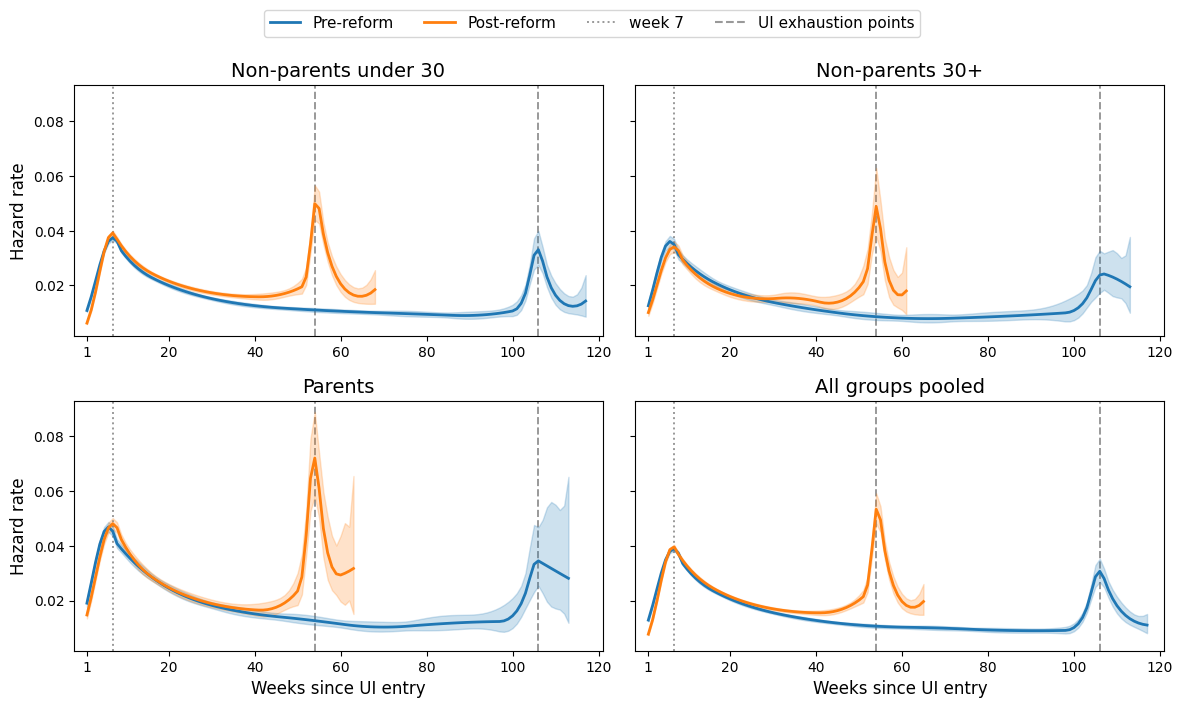

In [3]:
from matplotlib.lines import Line2D
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

x_pre_u    = np.arange(1,len(df_pre_nonpar_u30["HR_logit"]) +1)
x_post_u   = np.arange(1,len(df_post_nonpar_u30["HR_logit"]) +1)
x_pre_o    = np.arange(1,len(df_pre_nonpar_o30["HR_logit"]) +1)
x_post_o   = np.arange(1,len(df_post_nonpar_o30["HR_logit"]) +1)
x_pre_par  = np.arange(1,len(df_pre_par["HR_logit"]) +1)
x_post_par = np.arange(1,len(df_post_par["HR_logit"]) +1)
x_pre_agg  = np.arange(1,len(df_pre_agg["HR_logit"]) +1)
x_post_agg = np.arange(1,len(df_post_agg["HR_logit"]) +1)

width = 2

mpl.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 11,
})

def add_reference_lines(ax):
    # Week at which the initial transition increase peaks
    ax.axvline(
        x=7,
        color="0.6",
        linestyle="dotted",
        linewidth=1.4,
        zorder=0
    )

    # UI exhaustion points
    ax.axvline(
        x=54,
        color="0.6",
        linestyle="--",
        linewidth=1.4,
        zorder=0
    )
    ax.axvline(
        x=106,
        color="0.6",
        linestyle="--",
        linewidth=1.4,
        zorder=0
    )

def plot_panel(ax, x_pre, x_post, df_pre, df_post, title):
    add_reference_lines(ax)

    ax.plot(
        x_pre, df_pre["HR_logit"],
        color="C0", linewidth=width, label="Pre-reform"
    )
    ax.fill_between(
        x_pre, df_pre["Lower_CI"], df_pre["Upper_CI"],
        color="C0", alpha=0.22
    )

    ax.plot(
        x_post, df_post["HR_logit"],
        color="tab:orange", linewidth=width, label="Post-reform"
    )
    ax.fill_between(
        x_post, df_post["Lower_CI"], df_post["Upper_CI"],
        color="tab:orange", alpha=0.22
    )

    ax.set_title(title, fontweight="normal")


# ── Plot 2x2 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
ax1, ax2 = axes[0, 0], axes[0, 1]
ax3, ax4 = axes[1, 0], axes[1, 1]

plot_panel(
    ax1, x_pre_u, x_post_u,
    df_pre_nonpar_u30, df_post_nonpar_u30,
    "Non-parents under 30"
)

plot_panel(
    ax2, x_pre_o, x_post_o,
    df_pre_nonpar_o30, df_post_nonpar_o30,
    "Non-parents 30+"
)

plot_panel(
    ax3, x_pre_par, x_post_par,
    df_pre_par, df_post_par,
    "Parents"
)

plot_panel(
    ax4, x_pre_agg, x_post_agg,
    df_pre_agg, df_post_agg,
    "All groups pooled"
)

# Axis labels
axes[0, 0].set_xlabel("")
axes[0, 1].set_xlabel("")

axes[0, 0].set_ylabel("Hazard rate", fontsize=12)
axes[1, 0].set_ylabel("Hazard rate", fontsize=12)

axes[1, 0].set_xlabel("Weeks since UI entry")
axes[1, 1].set_xlabel("Weeks since UI entry")

# x limits
x_pad_left = 3
x_pad_right = 3

for ax in axes.flat:
    ax.set_xlim(1 - x_pad_left, x_trim_pre + 1 + x_pad_right)
    ax.set_xticks([1, 20, 40, 60, 80, 100, 120])
    ax.title.set_fontsize(14)
    ax.title.set_fontweight("normal")

# One common legend
legend_handles = [
    Line2D([0], [0], color="C0", lw=2, label="Pre-reform"),
    Line2D([0], [0], color="tab:orange", lw=2, label="Post-reform"),
    Line2D([0], [0], color="0.6", lw=1.4, linestyle="dotted", label="week 7"),
    Line2D([0], [0], color="0.6", lw=1.5, linestyle="--", label="UI exhaustion points")
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    frameon=True,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
#plt.savefig("data_hr.pdf", bbox_inches="tight")
plt.show()

### Plot fit of model for log and shifted-log specification

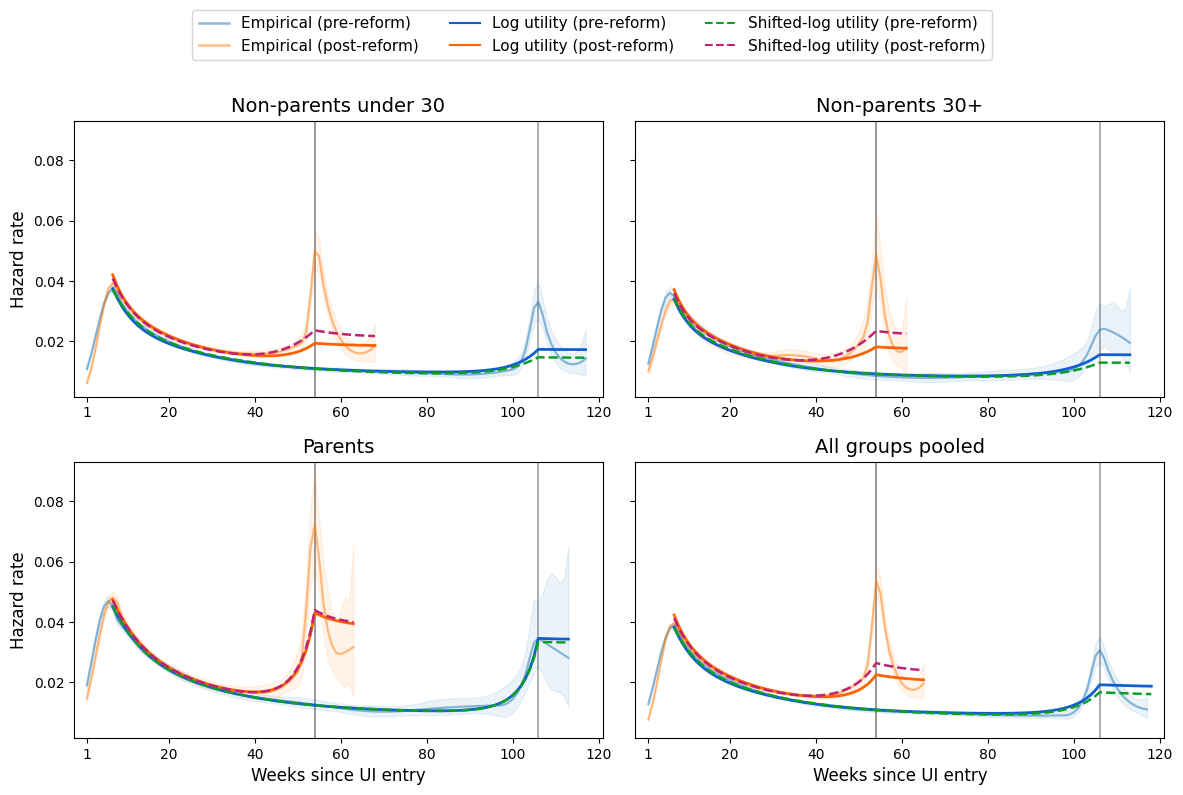

In [5]:

# ── load empirical data ───────────────────────────────────────────────────────
emp = {
    "pre1":     df_pre_nonpar_u30,
    "post1":    df_post_nonpar_u30,
    "pre2":     df_pre_nonpar_o30,
    "post2":    df_post_nonpar_o30,
    "pre3":     df_pre_par,
    "post3":    df_post_par,
    "agg_pre":  df_pre_agg,
    "agg_post": df_post_agg,
}

# ── load simulated data ───────────────────────────────────────────────────────
log = {
    "pre1":     pd.read_csv("output/pre1_simulated_log.csv"),
    "post1":    pd.read_csv("output/post1_simulated_log.csv"),
    "pre2":     pd.read_csv("output/pre2_simulated_log.csv"),
    "post2":    pd.read_csv("output/post2_simulated_log.csv"),
    "pre3":     pd.read_csv("output/pre3_simulated_log.csv"),
    "post3":    pd.read_csv("output/post3_simulated_log.csv"),
    "agg_pre":  pd.read_csv("output/agg_pre_simulated_log.csv"),
    "agg_post": pd.read_csv("output/agg_post_simulated_log.csv"),
}

slog = {
    "pre1":     pd.read_csv("output/pre1_simulated_logshift.csv"),
    "post1":    pd.read_csv("output/post1_simulated_logshift.csv"),
    "pre2":     pd.read_csv("output/pre2_simulated_logshift.csv"),
    "post2":    pd.read_csv("output/post2_simulated_logshift.csv"),
    "pre3":     pd.read_csv("output/pre3_simulated_logshift.csv"),
    "post3":    pd.read_csv("output/post3_simulated_logshift.csv"),
    "agg_pre":  pd.read_csv("output/agg_pre_simulated_logshift.csv"),
    "agg_post": pd.read_csv("output/agg_post_simulated_logshift.csv"),
}
# ── colors ────────────────────────────────────────────────────────────────────
c_emp_pre   = "C0"#"#1a6faf"   # deep blue        — empirical pre
c_emp_post  = "tab:orange"#"#d94801"   # deep orange      — empirical post

c_log_pre   = "#115ed2"   # deep blue        — log pre
c_log_post  = "#ff6200"   # deep orange      — log post

c_slog_pre  = "#0b9f29"   # deep green       — shift-log pre
c_slog_post = "#bd2273"   # deep purple      — shift-log post

mpl.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 11,
})

x_trim_pre = max(len(emp["pre1"]),
                 len(emp["pre2"]),
                 len(emp["pre3"]))

# ── helpers ───────────────────────────────────────────────────────────────────
def add_reference_lines(ax):
    ax.axvline(x=54,  color="0.60", linestyle="-", linewidth=1.4, zorder=0)
    ax.axvline(x=106, color="0.60", linestyle="-", linewidth=1.4,
               alpha=0.8, zorder=0)
def plot_panel(ax, pre_key, post_key, title):
    add_reference_lines(ax)

    # empirical — start from 1
    x_emp_pre  = np.arange(1, len(emp[pre_key]) + 1)
    x_emp_post = np.arange(1, len(emp[post_key]) + 1)

    ax.plot(x_emp_pre,  emp[pre_key]["HR_logit"],
            color=c_emp_pre,  lw=1.6, linestyle="-", alpha=0.5)
    ax.fill_between(x_emp_pre,
                    emp[pre_key]["Lower_CI"], emp[pre_key]["Upper_CI"],
                    color=c_emp_pre, alpha=0.086)

    ax.plot(x_emp_post, emp[post_key]["HR_logit"],
            color=c_emp_post, lw=1.6, linestyle="-", alpha=0.5)
    ax.fill_between(x_emp_post,
                    emp[post_key]["Lower_CI"], emp[post_key]["Upper_CI"],
                    color=c_emp_post, alpha=0.086)

    # log — week + 1
    ax.plot(log[pre_key]["week"] + 1,  log[pre_key]["hr"],
            color=c_log_pre,  lw=2, linestyle="-")
    ax.plot(log[post_key]["week"] + 1, log[post_key]["hr"],
            color=c_log_post, lw=2, linestyle="-")

    # shift-log — week + 1
    ax.plot(slog[pre_key]["week"] + 1,  slog[pre_key]["hr"],
            color=c_slog_pre,  lw=1.8, linestyle="--")
    ax.plot(slog[post_key]["week"] + 1, slog[post_key]["hr"],
            color=c_slog_post, lw=1.8, linestyle="--")

    ax.set_title(title, fontweight="normal")

# ── 2x2 figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 7.7), sharey=True)
ax1, ax2  = axes[0, 0], axes[0, 1]
ax3, ax4  = axes[1, 0], axes[1, 1]

plot_panel(ax1, "pre1",    "post1",    "Non-parents under 30")
plot_panel(ax2, "pre2",    "post2",    "Non-parents 30+")
plot_panel(ax3, "pre3",    "post3",    "Parents")
plot_panel(ax4, "agg_pre", "agg_post", "All groups pooled")

# ── axis labels ───────────────────────────────────────────────────────────────
axes[0, 0].set_ylabel("Hazard rate")
axes[1, 0].set_ylabel("Hazard rate")
axes[1, 0].set_xlabel("Weeks since UI entry")
axes[1, 1].set_xlabel("Weeks since UI entry")
axes[0, 0].set_xlabel("")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("")
axes[1, 1].set_ylabel("")

x_pad_left, x_pad_right = 3, 3
for ax in axes.flat:
    ax.set_xlim(1 - x_pad_left, x_trim_pre + 1 + x_pad_right)
    ax.set_xticks([1, 20, 40, 60, 80, 100, 120])
    ax.title.set_fontsize(14)
    ax.title.set_fontweight("normal")
legend_handles = [
    Line2D([0], [0], color=c_emp_pre,   lw=1.8, linestyle="-",  alpha=0.5, label="Empirical (pre-reform)"),
    Line2D([0], [0], color=c_emp_post,  lw=1.8, linestyle="-",  alpha=0.5, label="Empirical (post-reform)"),
    Line2D([0], [0], color=c_log_pre,   lw=1.5, linestyle="-",             label="Log utility (pre-reform)"),
    Line2D([0], [0], color=c_log_post,  lw=1.5, linestyle="-",             label="Log utility (post-reform)"),
    Line2D([0], [0], color=c_slog_pre,  lw=1.5, linestyle="--",            label="Shifted-log utility (pre-reform)"),
    Line2D([0], [0], color=c_slog_post, lw=1.5, linestyle="--",            label="Shifted-log utility (post-reform)"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, 1.04),
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
#plt.savefig("model_fit_comparison.pdf", bbox_inches="tight")
plt.show()

### Make plot for week-12 reduction  appendix

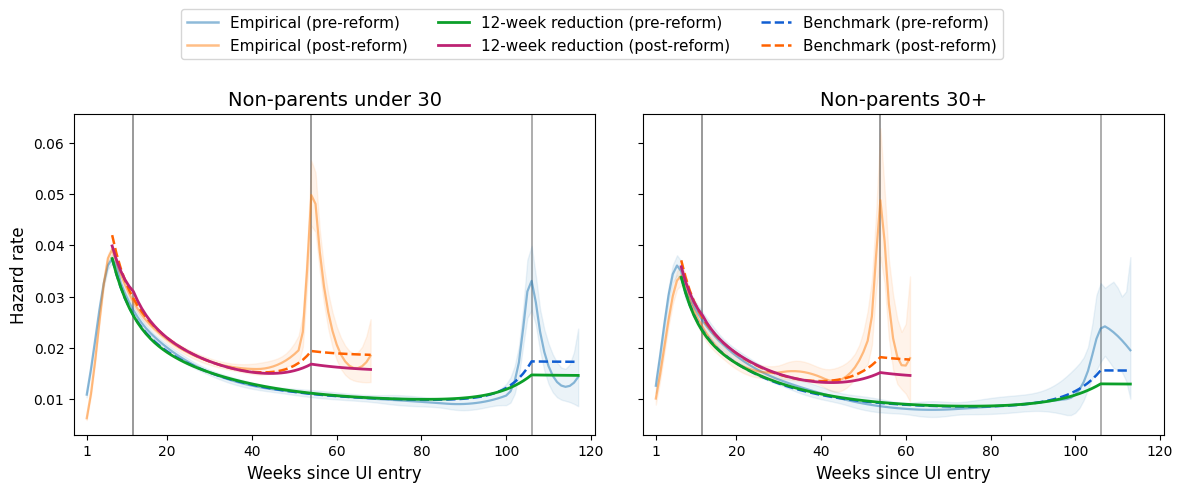

In [9]:

# ── Load data ─────────────────────────────────────────────────────────────────
emp  = {"pre1": df_pre_nonpar_u30, "post1": df_post_nonpar_u30, "pre2": df_pre_nonpar_o30, "post2": df_post_nonpar_o30}
log  = {k: pd.read_csv(f"output/{k}_simulated_log.csv")    for k in ["pre1","post1","pre2","post2"]}
slog = {k: pd.read_csv(f"output/{k}_simulated_log_12.csv") for k in ["pre1","post1","pre2","post2"]}

# ── Colors ────────────────────────────────────────────────────────────────────
c_emp_pre, c_emp_post   = "C0", "tab:orange"
c_log_pre, c_log_post   = "#115ed2", "#ff6200"
c_slog_pre, c_slog_post = "#0b9f29", "#bd2273"

# ── Typography ────────────────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 11,
})

x_trim = max(len(emp[k]) for k in emp)

# ── Helpers ───────────────────────────────────────────────────────────────────
def add_reference_lines(ax):
    for x, alpha in [(12, 1.0), (54, 1.0), (106, 0.8)]:
        ax.axvline(x=x, color="0.60", linestyle="-", linewidth=1.4, alpha=alpha, zorder=0)

def plot_panel(ax, pre_key, post_key, title):
    add_reference_lines(ax)
    for key, color in [(pre_key, c_emp_pre), (post_key, c_emp_post)]:
        x = np.arange(1, len(emp[key]) + 1)
        ax.plot(x, emp[key]["HR_logit"], color=color, linewidth=1.6, linestyle="-", alpha=0.5)
        ax.fill_between(x, emp[key]["Lower_CI"], emp[key]["Upper_CI"], color=color, alpha=0.086)

    for key, color in [(pre_key, c_log_pre), (post_key, c_log_post)]:
        ax.plot(log[key]["week"] + 1, log[key]["hr"], color=color, linewidth=1.8, linestyle="--")

    for key, color in [(pre_key, c_slog_pre), (post_key, c_slog_post)]:
        ax.plot(slog[key]["week"] + 1, slog[key]["hr"], color=color, linewidth=2, linestyle="-")

    ax.set_title(title, fontsize=14, fontweight="normal")
    ax.set_xlabel("Weeks since UI entry")
    ax.grid(False)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7), sharey=True)
plot_panel(axes[0], "pre1", "post1", "Non-parents under 30")
plot_panel(axes[1], "pre2", "post2", "Non-parents 30+")

axes[0].set_ylabel("Hazard rate")
axes[1].set_ylabel("")
for ax in axes:
    ax.set_xlim(1 - 3, x_trim + 1 + 3)
    ax.set_xticks([1, 20, 40, 60, 80, 100, 120])

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], color=c_emp_pre,  linewidth=1.8, linestyle="-",  alpha=0.5, label="Empirical (pre-reform)"),
    Line2D([0], [0], color=c_emp_post, linewidth=1.8, linestyle="-",  alpha=0.5, label="Empirical (post-reform)"),
    Line2D([0], [0], color=c_slog_pre, linewidth=2,   linestyle="-",             label="12-week reduction (pre-reform)"),
    Line2D([0], [0], color=c_slog_post,linewidth=2,   linestyle="-",             label="12-week reduction (post-reform)"),
    Line2D([0], [0], color=c_log_pre,  linewidth=1.8, linestyle="--",            label="Benchmark (pre-reform)"),
    Line2D([0], [0], color=c_log_post, linewidth=1.8, linestyle="--",            label="Benchmark (post-reform)"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=True, bbox_to_anchor=(0.5, 1.06))

plt.tight_layout(rect=[0, 0, 1, 0.91], w_pad=2.0)
#plt.savefig("model_fit_log_vs_log12.pdf", bbox_inches="tight")
plt.show()

### Make plot for spline appendix

In [10]:
def add_knot_lines(ax, knots, color="0.65", linestyle="--", linewidth=0.9, alpha=0.8):
    for k in knots:
        ax.axvline(
            k,
            color=color,
            linestyle=linestyle,
            linewidth=linewidth,
            alpha=alpha,
            zorder=0
        )

In [11]:
# knot placements 
k_nonpar_pre_o30_1 = [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 76, 80, 84, 90, 95, 100, 103, 106, 112]
k_nonpar_pre_o30_fin = [0,7, 15, 30, 45, 60, 70, 97, 103, 106, 112]
k_nonpar_post_o30_1 = [0, 3, 6, 9, 12, 15, 18, 20, 23, 26, 29, 32, 35, 38, 41, 44, 47, 50, 52, 54, 56, 59]
k_nonpar_post_o30_fin = [0, 8, 15, 30, 40, 50, 52, 54, 61]
k_nonpar_pre_u30 = [0, 8, 15, 28, 45, 70, 85, 99, 103, 106, 117]
k_nonpar_post_u30 = [0, 7, 15, 40, 50, 52, 54, 68]
k_par_pre = [0,7,15,30,45,60,75,96,103,105,113]
k_par_post = [0,8,15,40,49,51,54,59,63]
k_agg_pre = [0,8,15,30,45,60,75,97,103,106,117]
k_agg_post = [0,8,15,40,50,52,54,65]

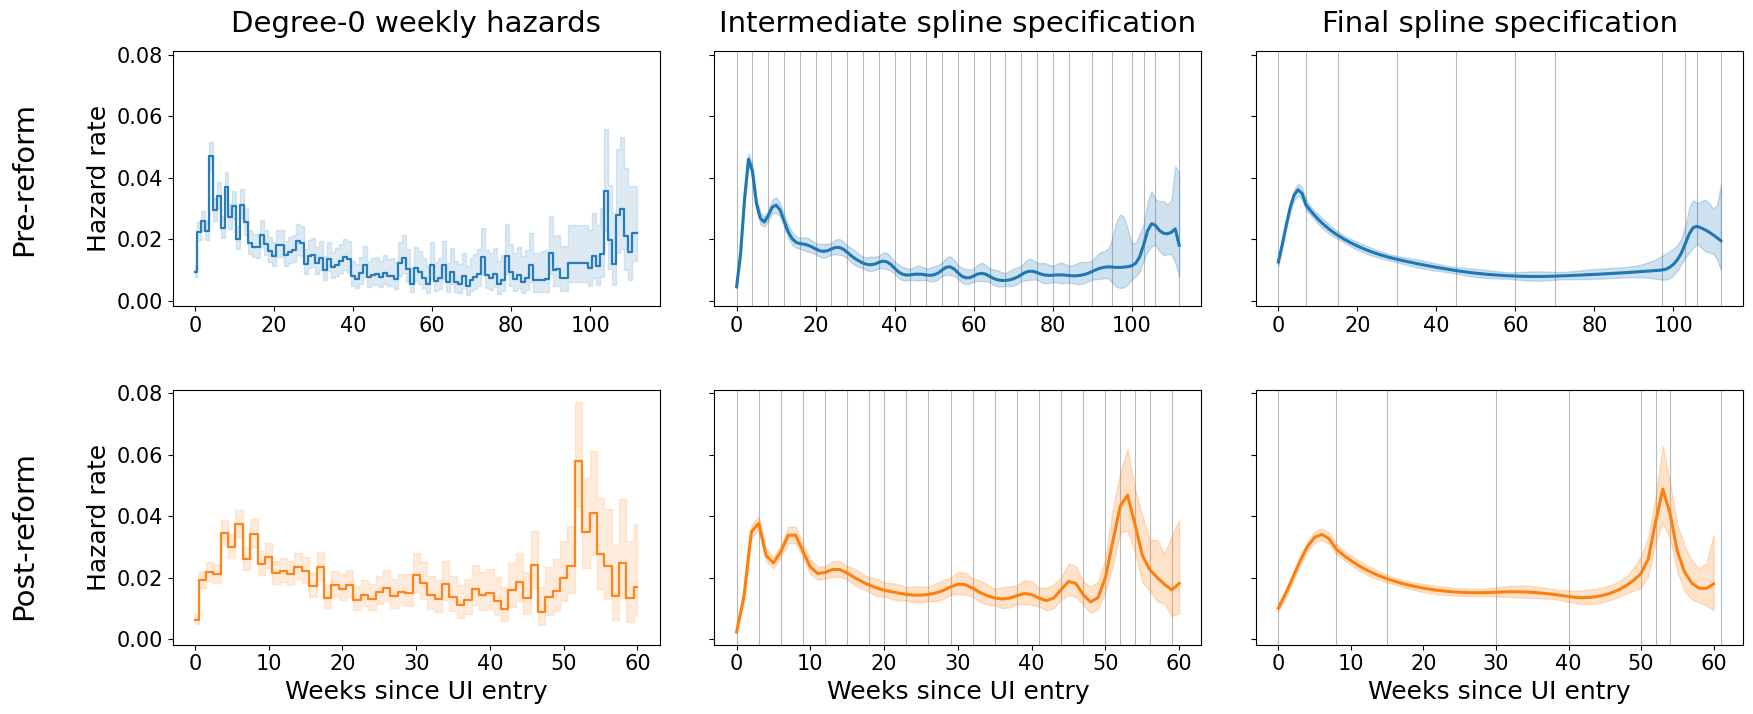

In [12]:
# Typography
mpl.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 21,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 16.5,
})

TITLE_SIZE = 21
LABEL_SIZE = 18
TICK_SIZE = 15
ROW_SIZE = 21
LEGEND_SIZE = 16.5


# ── Style settings ────────────────────────────────────────────────────────────
pre_color, post_color, knot_color = "C0", "C1", "0.65"
raw_lw, spline_lw, knot_lw = 1.6, 2.2, 0.8
raw_line_alpha, raw_ci_alpha, spline_ci_alpha, knot_alpha = 0.95, 0.15, 0.22, 0.8

# ── Helpers ───────────────────────────────────────────────────────────────────
def add_knot_lines(ax, knots):
    if knots is None: return
    for knot in knots:
        ax.axvline(x=knot, color=knot_color, linestyle="-", linewidth=knot_lw, alpha=knot_alpha, zorder=0)

def plot_process_panel(ax, df, line_color, title=None, raw=False, knots=None):
    x = np.arange(len(df))
    add_knot_lines(ax, knots)
    if raw:
        ax.step(x, df["HR_logit"], where="mid", color=line_color, linewidth=raw_lw, alpha=raw_line_alpha, zorder=2)
        ax.fill_between(x, df["Lower_CI"], df["Upper_CI"], step="mid", color=line_color, alpha=raw_ci_alpha, zorder=1)
    else:
        ax.plot(x, df["HR_logit"], color=line_color, linewidth=spline_lw, zorder=3)
        ax.fill_between(x, df["Lower_CI"], df["Upper_CI"], color=line_color, alpha=spline_ci_alpha, zorder=2)
    if title is not None:
        ax.set_title(title, fontsize=TITLE_SIZE, fontweight="normal", pad=14)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 8.5), sharex=False, sharey=True)

col_titles = ["Degree-0 weekly hazards", "Intermediate spline specification", "Final spline specification"]

# top row: pre-reform
plot_process_panel(axes[0, 0], df_pre_nonpar_o30_raw, pre_color,  raw=True,  knots=None,                title=col_titles[0])
plot_process_panel(axes[0, 1], df_pre_nonpar_o30_2,   pre_color,  raw=False, knots=k_nonpar_pre_o30_1,  title=col_titles[1])
plot_process_panel(axes[0, 2], df_pre_nonpar_o30,     pre_color,  raw=False, knots=k_nonpar_pre_o30_fin, title=col_titles[2])

# bottom row: post-reform
plot_process_panel(axes[1, 0], df_post_nonpar_o30_raw, post_color, raw=True,  knots=None)
plot_process_panel(axes[1, 1], df_post_nonpar_o30_2,   post_color, raw=False, knots=k_nonpar_post_o30_1)
plot_process_panel(axes[1, 2], df_post_nonpar_o30,     post_color, raw=False, knots=k_nonpar_post_o30_fin)

# ── Axis labels ───────────────────────────────────────────────────────────────
for row in range(2):
    for col in range(3):
        axes[row, col].set_ylabel("Hazard rate" if col == 0 else "", fontsize=LABEL_SIZE)
        axes[row, col].set_xlabel("Weeks since UI entry" if row == 1 else "", fontsize=LABEL_SIZE)

# ── Row headers ───────────────────────────────────────────────────────────────
fig.text(0.03, 0.69, "Pre-reform",  rotation=90, va="center", ha="center", fontsize=ROW_SIZE)
fig.text(0.03, 0.27, "Post-reform", rotation=90, va="center", ha="center", fontsize=ROW_SIZE)

# ── Legend (commented out) ────────────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], color="black",    linewidth=raw_lw,    drawstyle="steps-mid", label="Degree-0 hazard"),
    Line2D([0], [0], color="black",    linewidth=spline_lw,                        label="Spline"),
    Line2D([0], [0], color=knot_color, linewidth=knot_lw,   linestyle="--",        label="Knot placement"),
]

# ── Layout and export ─────────────────────────────────────────────────────────
plt.tight_layout(rect=[0.05, 0.04, 1, 0.92], w_pad=2.0, h_pad=2.0)
#plt.savefig("spline_o30.pdf", bbox_inches="tight")
plt.show()


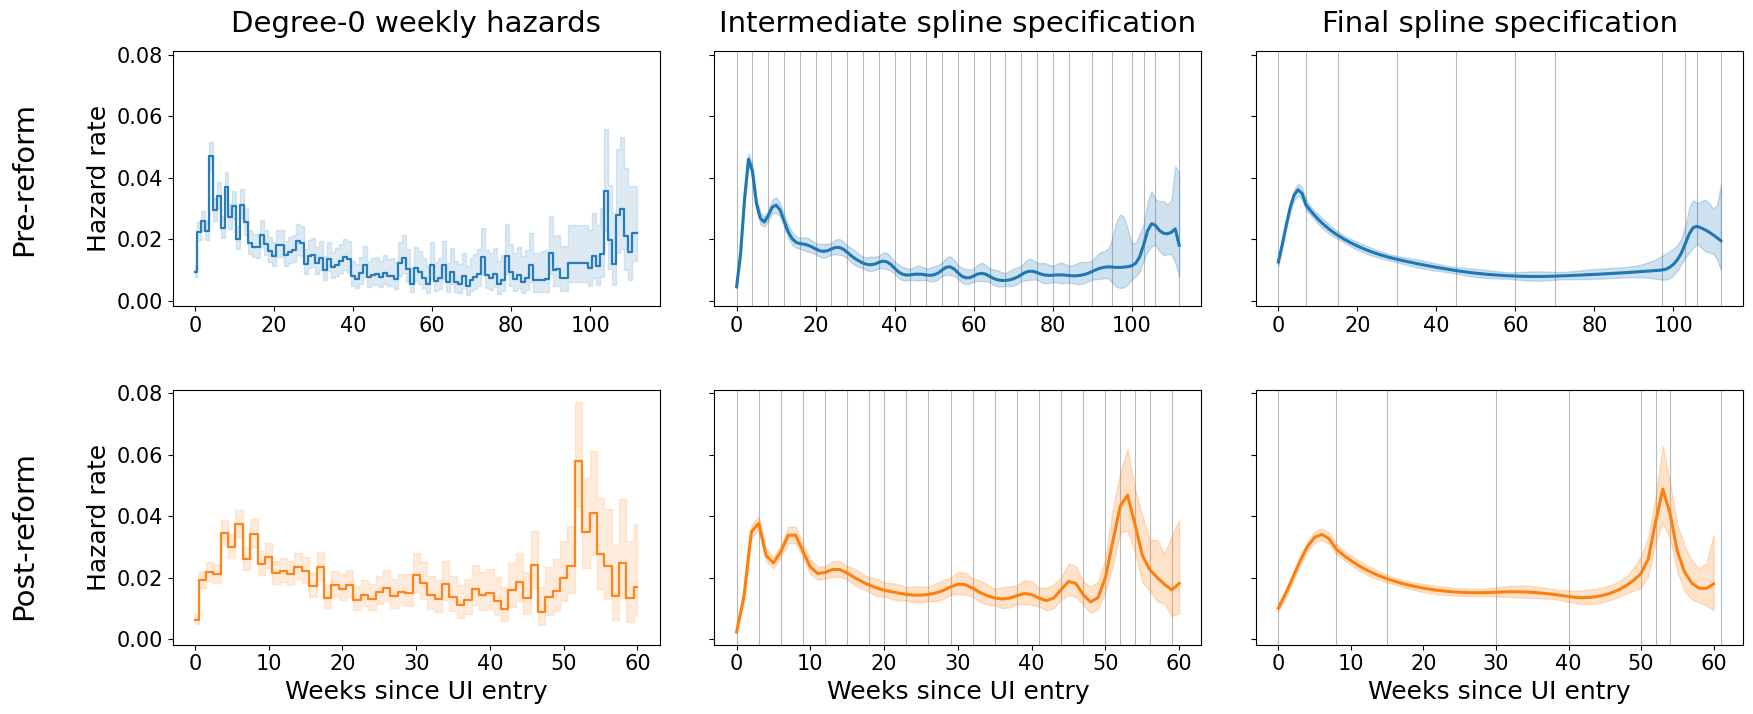

In [13]:
# ── Typography ────────────────────────────────────────────────────────────────

mpl.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 21,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 16.5,
})

title_fs = 21
label_fs = 18
tick_fs = 15
row_fs = 21
legend_fs = 16.5

# ── Style settings ────────────────────────────────────────────────────────────
pre_color, post_color, knot_color = "C0", "C1", "0.65"
raw_lw, spline_lw, knot_lw = 1.6, 2.2, 0.8
raw_line_alpha, raw_ci_alpha, spline_ci_alpha, knot_alpha = 0.95, 0.15, 0.22, 0.8

# ── Helpers ───────────────────────────────────────────────────────────────────
def add_knot_lines(ax, knots):
    if knots is None: return
    for knot in knots:
        ax.axvline(x=knot, color=knot_color, linestyle="-", linewidth=knot_lw, alpha=knot_alpha, zorder=0)

def plot_process_panel(ax, df, line_color, title=None, raw=False, knots=None):
    x = np.arange(len(df))
    add_knot_lines(ax, knots)
    if raw:
        ax.step(x, df["HR_logit"], where="mid", color=line_color, linewidth=raw_lw, alpha=raw_line_alpha, zorder=2)
        ax.fill_between(x, df["Lower_CI"], df["Upper_CI"], step="mid", color=line_color, alpha=raw_ci_alpha, zorder=1)
    else:
        ax.plot(x, df["HR_logit"], color=line_color, linewidth=spline_lw, zorder=3)
        ax.fill_between(x, df["Lower_CI"], df["Upper_CI"], color=line_color, alpha=spline_ci_alpha, zorder=2)
    if title is not None:
        ax.set_title(title, fontsize=TITLE_SIZE, fontweight="normal", pad=14)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 8.5), sharex=False, sharey=True)

col_titles = ["Degree-0 weekly hazards", "Intermediate spline specification", "Final spline specification"]

# top row: pre-reform
plot_process_panel(axes[0, 0], df_pre_nonpar_o30_raw, pre_color,  raw=True,  knots=None,                title=col_titles[0])
plot_process_panel(axes[0, 1], df_pre_nonpar_o30_2,   pre_color,  raw=False, knots=k_nonpar_pre_o30_1,  title=col_titles[1])
plot_process_panel(axes[0, 2], df_pre_nonpar_o30,     pre_color,  raw=False, knots=k_nonpar_pre_o30_fin, title=col_titles[2])

# bottom row: post-reform
plot_process_panel(axes[1, 0], df_post_nonpar_o30_raw, post_color, raw=True,  knots=None)
plot_process_panel(axes[1, 1], df_post_nonpar_o30_2,   post_color, raw=False, knots=k_nonpar_post_o30_1)
plot_process_panel(axes[1, 2], df_post_nonpar_o30,     post_color, raw=False, knots=k_nonpar_post_o30_fin)

# ── Axis labels ───────────────────────────────────────────────────────────────
for row in range(2):
    for col in range(3):
        axes[row, col].set_ylabel("Hazard rate" if col == 0 else "", fontsize=LABEL_SIZE)
        axes[row, col].set_xlabel("Weeks since UI entry" if row == 1 else "", fontsize=LABEL_SIZE)

# ── Row headers ───────────────────────────────────────────────────────────────
fig.text(0.03, 0.69, "Pre-reform",  rotation=90, va="center", ha="center", fontsize=ROW_SIZE)
fig.text(0.03, 0.27, "Post-reform", rotation=90, va="center", ha="center", fontsize=ROW_SIZE)

# ── Legend (commented out) ────────────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], color="black",    linewidth=raw_lw,    drawstyle="steps-mid", label="Degree-0 hazard"),
    Line2D([0], [0], color="black",    linewidth=spline_lw,                        label="Spline"),
    Line2D([0], [0], color=knot_color, linewidth=knot_lw,   linestyle="--",        label="Knot placement"),
]

# ── Layout and export ─────────────────────────────────────────────────────────
plt.tight_layout(rect=[0.05, 0.04, 1, 0.92], w_pad=2.0, h_pad=2.0)
#plt.savefig("spline_o30.pdf", bbox_inches="tight")
plt.show()

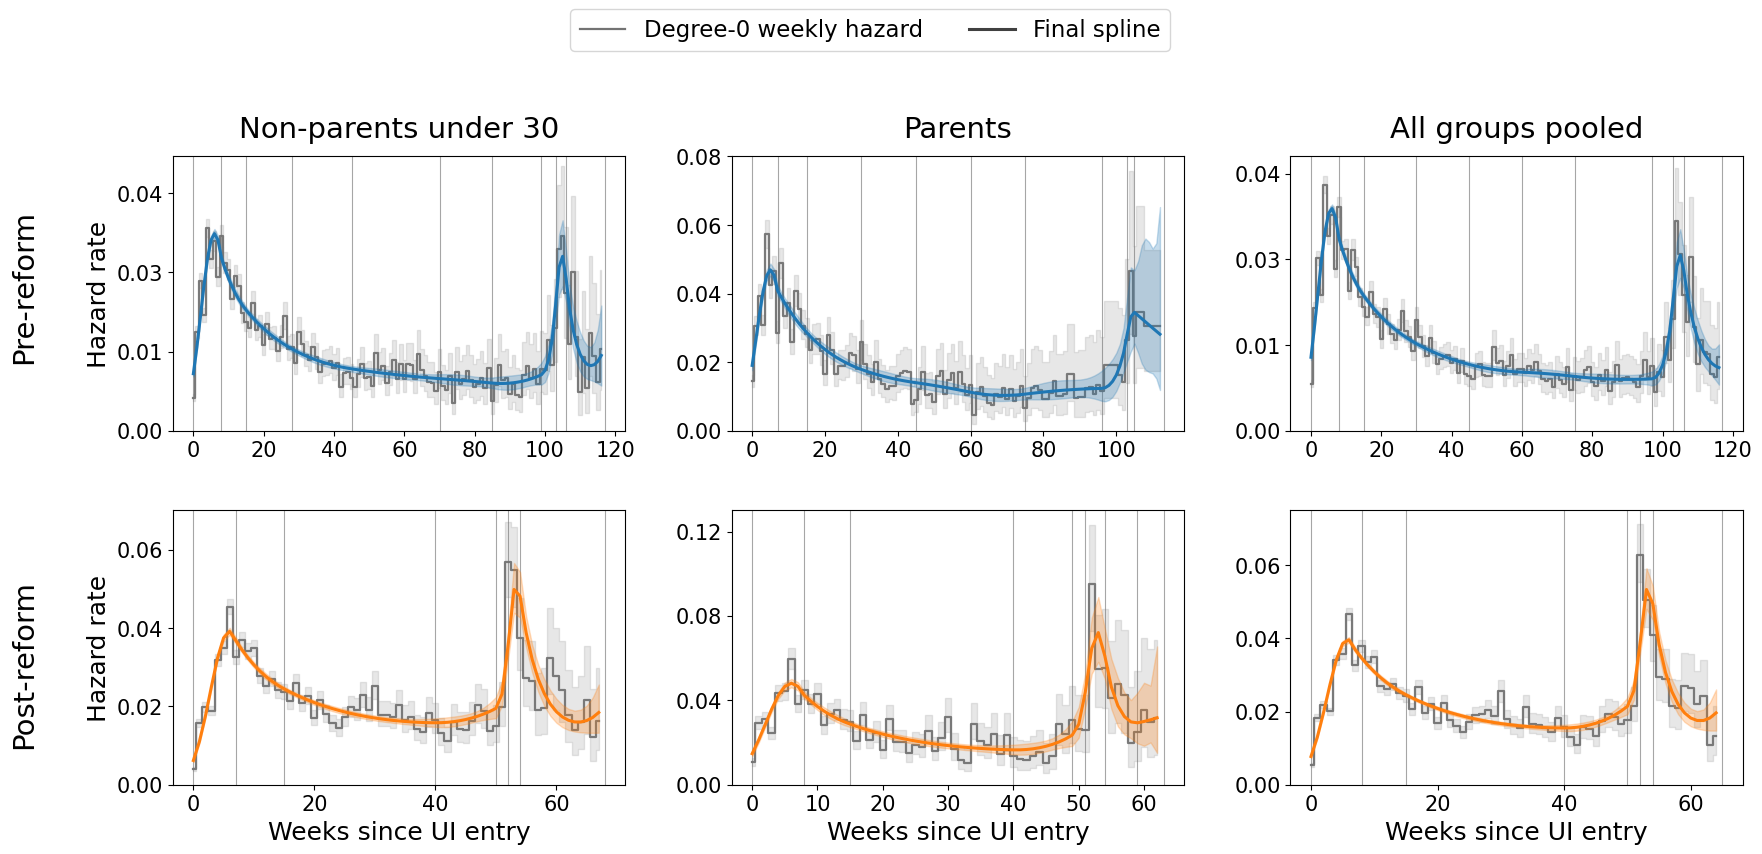

In [17]:
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

# ── Typography ────────────────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.size": 18, "axes.titlesize": 21, "axes.labelsize": 18,
    "xtick.labelsize": 15, "ytick.labelsize": 15, "legend.fontsize": 16.5,
})
title_fs, label_fs, tick_fs, row_fs, legend_fs = 21, 18, 15, 21, 16.5

# ── Style settings ────────────────────────────────────────────────────────────
raw_color, pre_color, post_color = "0.45", "C0", "C1"
raw_lw, final_lw = 1.6, 2.2
raw_line_alpha, raw_ci_alpha, final_ci_alpha = 0.95, 0.17, 0.25
knot_color, knot_lw, knot_alpha = "0.65", 0.8, 1

# ── Helpers ───────────────────────────────────────────────────────────────────
def add_knot_lines(ax, knots):
    if knots is None: return
    for knot in knots:
        ax.axvline(x=knot, color=knot_color, linestyle="-", linewidth=knot_lw, alpha=knot_alpha, zorder=0)

def plot_raw_vs_final_single(ax, df_raw, df_final, final_color, knots=None, title=None):
    x_raw, x_final = np.arange(len(df_raw)), np.arange(len(df_final))
    add_knot_lines(ax, knots)
    ax.step(x_raw, df_raw["HR_logit"], where="mid", color=raw_color, linewidth=raw_lw, alpha=raw_line_alpha, zorder=2)
    ax.fill_between(x_raw, df_raw["Lower_CI"], df_raw["Upper_CI"], step="mid", color=raw_color, alpha=raw_ci_alpha, zorder=1)
    ax.plot(x_final, df_final["HR_logit"], color=final_color, linewidth=final_lw, zorder=4)
    ax.fill_between(x_final, df_final["Lower_CI"], df_final["Upper_CI"], color=final_color, alpha=final_ci_alpha, zorder=3)
    if title is not None:
        ax.set_title(title, fontsize=title_fs, fontweight="normal", pad=14)
    ax.tick_params(axis="both", labelsize=tick_fs)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=False, sharey=False)
col_titles = ["Non-parents under 30", "Parents", "All groups pooled"]

# top row: pre-reform
plot_raw_vs_final_single(axes[0, 0], df_pre_nonpar_u30_raw, df_pre_nonpar_u30, pre_color,  knots=k_nonpar_pre_u30, title=col_titles[0])
plot_raw_vs_final_single(axes[0, 1], df_pre_par_raw,        df_pre_par,        pre_color,  knots=k_par_pre,        title=col_titles[1])
plot_raw_vs_final_single(axes[0, 2], df_pre_agg_raw,        df_pre_agg,        pre_color,  knots=k_agg_pre,        title=col_titles[2])

# bottom row: post-reform
plot_raw_vs_final_single(axes[1, 0], df_post_nonpar_u30_raw, df_post_nonpar_u30, post_color, knots=k_nonpar_post_u30)
plot_raw_vs_final_single(axes[1, 1], df_post_par_raw,         df_post_par,        post_color, knots=k_par_post)
plot_raw_vs_final_single(axes[1, 2], df_post_agg_raw,         df_post_agg,        post_color, knots=k_agg_post)

# ── Y limits and tick formatting ──────────────────────────────────────────────
y_limits = {(0,0): (0, 0.052), (0,1): (0, 0.080), (0,2): (0, 0.048),
            (1,0): (0, 0.070), (1,1): (0, 0.130), (1,2): (0, 0.075)}

for (row, col), limits in y_limits.items():
    ax = axes[row, col]
    ax.set_ylim(*limits)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, min_n_ticks=4))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

# ── Axis labels ───────────────────────────────────────────────────────────────
for row in range(2):
    for col in range(3):
        axes[row, col].set_ylabel("Hazard rate" if col == 0 else "", fontsize=label_fs)
        axes[row, col].set_xlabel("Weeks since UI entry" if row == 1 else "", fontsize=label_fs)

# ── Row headers ───────────────────────────────────────────────────────────────
fig.text(0.03, 0.69, "Pre-reform",  rotation=90, va="center", ha="center", fontsize=row_fs)
fig.text(0.03, 0.27, "Post-reform", rotation=90, va="center", ha="center", fontsize=row_fs)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], color=raw_color, linewidth=raw_lw, drawstyle="steps-mid", label="Degree-0 weekly hazard"),
    Line2D([0], [0], color="0.25",    linewidth=final_lw,                       label="Final spline"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, frameon=True, fontsize=legend_fs, bbox_to_anchor=(0.5, 1.01))

# ── Layout and export ─────────────────────────────────────────────────────────
plt.tight_layout(rect=[0.05, 0.04, 1, 0.91], w_pad=2.0, h_pad=2.0)
#plt.savefig("spline_all.pdf", bbox_inches="tight")
plt.show()